# SQL Practice Notebook

This notebook is for building SQL skills, starting from basic queries and working up to more complex patterns. Each section focuses on one concept.

In [1]:
from olist_analytics.db import setup
engine, q = setup()

Connected.


### All Tables

List every table in the database.

In [2]:
q("""
  SELECT relname AS table_name
  FROM pg_stat_user_tables
  ORDER BY relname ASC
""")

,table_name
0,olist_customers
1,olist_geolocation
2,olist_order_items
3,olist_order_payments
4,olist_order_reviews
5,olist_orders
6,olist_product_category_name_translation
7,olist_products
8,olist_sellers


### 2.1 SELECT *

Return every column from a table. Use `LIMIT` to avoid loading the entire table.

Select all columns from `olist_customers`.

In [3]:
q("""
  SELECT *
  FROM olist_customers
  LIMIT 5
""")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Select all columns from `olist_orders`.

In [4]:
q("""
  SELECT *
  FROM olist_orders
  LIMIT 5
""")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


Select all columns from `olist_products`.

In [5]:
q("""
  SELECT *
  FROM olist_products
  LIMIT 5
""")

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625.0,20.0,17.0,13.0


### 2.2 SELECT specific columns

Only return the columns you need. More efficient than `SELECT *` for large tables.

Select `customer_id`, `customer_city`, `customer_state` from `olist_customers`.

In [6]:
q("""
  SELECT customer_id, customer_city, customer_state
  FROM olist_customers
  LIMIT 5
""")

,customer_id,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,campinas,SP


Select `order_id`, `order_status`, `order_purchase_timestamp` from `olist_orders`.

In [7]:
q("""
  SELECT order_id, order_status, order_purchase_timestamp
  FROM olist_orders
  LIMIT 5
""")

,order_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39


### 2.3 ORDER BY

Sort results. `ASC` is default (lowest to highest). `DESC` is highest to lowest. Multiple columns can be chained; the second column breaks ties in the first.

Return the 10 most recent orders from `olist_orders`.

In [8]:
q("""
  SELECT order_id, order_status, order_purchase_timestamp
  FROM olist_orders
  ORDER BY order_purchase_timestamp DESC
  LIMIT 10
""")

,order_id,order_status,order_purchase_timestamp
0,10a045cdf6a5650c21e9cfeb60384c16,canceled,2018-10-17 17:30:18
1,b059ee4de278302d550a3035c4cdb740,canceled,2018-10-16 20:16:02
2,a2ac6dad85cf8af5b0afb510a240fe8c,canceled,2018-10-03 18:55:29
3,616fa7d4871b87832197b2a137a115d2,canceled,2018-10-01 15:30:09
4,392ed9afd714e3c74767d0c4d3e3f477,canceled,2018-09-29 09:13:03
5,869997fbe01f39d184956b5c6bccfdbe,canceled,2018-09-26 08:40:15
6,5aac76cf7b07dd06fa4d50bf461d2f40,canceled,2018-09-25 11:59:18
7,ed3efbd3a87bea76c2812c66a0b32219,canceled,2018-09-20 13:54:16
8,bd35b677fd239386e9861d11ae98ab56,canceled,2018-09-17 17:21:16
9,ea844c92cf978ea23321fa7fe5871761,canceled,2018-09-13 09:56:12


Return the 10 heaviest products from `olist_products`. Exclude NULLs.

In [9]:
q("""
  SELECT product_id, product_category_name, product_weight_g
  FROM olist_products
  WHERE product_weight_g IS NOT NULL
  ORDER BY product_weight_g DESC
  LIMIT 10
""")

,product_id,product_category_name,product_weight_g
0,26644690fde745fc4654719c3904e1db,cama_mesa_banho,40425.0
1,dcfeedf441c38e5e7e58ffce194af2bb,beleza_saude,30000.0
2,1c57458e824ca3d974ec1831a1a55e72,pet_shop,30000.0
3,f97ad9066c718a6cef93dfcf253d3e0d,moveis_decoracao,30000.0
4,363a9f5b97bf194da23858be722a7aa5,construcao_ferramentas_construcao,30000.0
5,ceeba7d5636e59173cc5f484e913db3d,NaN,30000.0
6,c04e948c6900ce99ac47d89b3b6d70cd,cool_stuff,30000.0
7,d0877f0094337c414d23f5a3c7bad20c,moveis_escritorio,30000.0
8,53f92b0474f91fcb5bd188c6a8075c38,utilidades_domesticas,30000.0
9,0a859d8dc68f6a746b4709217110c439,esporte_lazer,30000.0


Return customers from `olist_customers` sorted alphabetically by state, then by city within each state.

In [10]:
q("""
  SELECT customer_id, customer_state, customer_city
  FROM olist_customers
  ORDER BY customer_state ASC, customer_city ASC
  LIMIT 5
""")

,customer_id,customer_state,customer_city
0,b1161707c5b3711b7cf6213c114c91b2,AC,brasileia
1,757bbd8c61a5fd67d5b8c18efd987beb,AC,cruzeiro do sul
2,ee0ab5a9747a11f916fff4b4fc306ac0,AC,cruzeiro do sul
3,f23c4b530f6d7d421de1e38d3e0cc327,AC,cruzeiro do sul
4,8a45f7d2b87f16a273fd86e9d5efc35a,AC,epitaciolandia


### 2.4 WHERE

Filter rows based on a condition. Applied before any aggregation.

Return only delivered orders from `olist_orders`.

In [11]:
q("""
  SELECT order_id, order_status, order_purchase_timestamp
  FROM olist_orders
  WHERE order_status = 'delivered'
  LIMIT 5
""")

,order_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39


Return customers from the state of SP from `olist_customers`.

In [12]:
q("""
  SELECT customer_id, customer_state
  FROM olist_customers
  WHERE customer_state = 'SP'
  LIMIT 5
""")

,customer_id,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,SP
1,18955e83d337fd6b2def6b18a428ac77,SP
2,4e7b3e00288586ebd08712fdd0374a03,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,SP


Return 5-star reviews from `olist_order_reviews`.

In [13]:
q("""
  SELECT review_id, order_id, review_score
  FROM olist_order_reviews
  WHERE review_score = 5
  LIMIT 5
""")

,review_id,order_id,review_score
0,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5
1,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5
2,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5
3,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5
4,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5


### 2.5 AND, OR, NOT

Combine multiple conditions. `AND` requires all conditions to be true. `OR` requires at least one. `!=` or `NOT` negates a condition.

Return delivered orders from customers in SP.

In [14]:
q("""
  SELECT c.customer_id, c.customer_state, o.order_id, o.order_status 
  FROM olist_customers c
  JOIN olist_orders o ON c.customer_id = o.customer_id
  WHERE o.order_status = 'delivered'
    AND c.customer_state = 'SP'
  LIMIT 5
""")

,customer_id,customer_state,order_id,order_status
0,00012a2ce6f8dcda20d059ce98491703,SP,5f79b5b0931d63f1a42989eb65b9da6e,delivered
1,000379cdec625522490c315e70c7a9fb,SP,0ab7fb08086d4af9141453c91878ed7a,delivered
2,0004164d20a9e969af783496f3408652,SP,cd3558a10d854487b4f907e9b326a4fc,delivered
3,0005aefbb696d34b3424dccd0a0e9fd0,SP,263ba12390d0fbce329dd16da8cd20f8,delivered
4,00062b33cb9f6fe976afdcff967ea74d,SP,c208db5638f7f1cd04d185856852f864,delivered


Return orders that are cancelled OR unavailable.

In [15]:
q("""
  SELECT order_id, order_status
  FROM olist_orders
  WHERE order_status = 'canceled'
    OR order_status = 'unavailable'
  LIMIT 5
""")

,order_id,order_status
0,8e24261a7e58791d10cb1bf9da94df5c,unavailable
1,1b9ecfe83cdc259250e1a8aca174f0ad,canceled
2,c272bcd21c287498b4883c7512019702,unavailable
3,714fb133a6730ab81fa1d3c1b2007291,canceled
4,37553832a3a89c9b2db59701c357ca67,unavailable


Return orders that are NOT delivered.

In [16]:
q("""
  SELECT order_id, order_status
  FROM olist_orders 
  WHERE order_status != 'delivered'
  LIMIT 5
""")

,order_id,order_status
0,136cce7faa42fdb2cefd53fdc79a6098,invoiced
1,ee64d42b8cf066f35eac1cf57de1aa85,shipped
2,0760a852e4e9d89eb77bf631eaaf1c84,invoiced
3,15bed8e2fec7fdbadb186b57c46c92f2,processing
4,6942b8da583c2f9957e990d028607019,shipped


### 2.6 IN, NOT IN

Match against a list of values. Cleaner than chaining multiple `OR` conditions.

Return orders with status `canceled`, `unavailable`, or `processing`.

In [17]:
q("""
  SELECT order_id, order_status 
  FROM olist_orders 
  WHERE order_status IN ('canceled', 'unavailable', 'processing')
  LIMIT 5
""")

,order_id,order_status
0,1b9ecfe83cdc259250e1a8aca174f0ad,canceled
1,714fb133a6730ab81fa1d3c1b2007291,canceled
2,3a129877493c8189c59c60eb71d97c29,canceled
3,00b1cb0320190ca0daa2c88b35206009,canceled
4,ed3efbd3a87bea76c2812c66a0b32219,canceled


Return customers NOT from SP or RJ.

In [18]:
q("""
  SELECT customer_id, customer_state
  FROM olist_customers
  WHERE customer_state NOT IN ('SP', 'RJ')
  LIMIT 5
""")

,customer_id,customer_state
0,879864dab9bc3047522c92c82e1212b8,SC
1,5e274e7a0c3809e14aba7ad5aae0d407,MG
2,5adf08e34b2e993982a47070956c5c65,PR
3,4b7139f34592b3a31687243a302fa75b,MG
4,9fb35e4ed6f0a14a4977cd9aea4042bb,MG


### 2.7 BETWEEN

Filter within a range. Inclusive on both ends.

Return orders placed in 2018.

In [19]:
q("""
  SELECT order_id, order_purchase_timestamp
  FROM olist_orders 
  WHERE order_purchase_timestamp BETWEEN '2018-01-01' AND '2018-12-31'
  ORDER BY order_purchase_timestamp ASC
  LIMIT 5
""")

,order_id,order_purchase_timestamp
0,4f6daad34df49e10c8072b33faafcb2a,2018-01-01 02:48:41
1,0462bad26ccfb8508951beb9ea398ae1,2018-01-01 08:37:46
2,fbe41a4974e4a492e085d90e5be0b3e3,2018-01-01 08:45:04
3,67a98eaf984ba84c596f9f5456634f20,2018-01-01 09:36:21
4,7d0a0773edc4bdca0ef6ab55777718a7,2018-01-01 10:24:03


Return products weighing between 1kg and 2kg.

In [20]:
q("""
  SELECT product_id, product_category_name, product_weight_g
  FROM olist_products
  WHERE product_weight_g BETWEEN 1000 AND 2000
  ORDER BY product_weight_g ASC
  LIMIT 5
""")

,product_id,product_category_name,product_weight_g
0,b521fddf2c8a7e7d1791bfb3c1b2f278,esporte_lazer,1000.0
1,8c9faf6aabee9b2a30b83f92d786f6de,livros_interesse_geral,1000.0
2,3aa071139cb16b67ca9e5dea641aaa2f,artes,1000.0
3,8efa775719397f78f79c8e5c7b0afbd4,moveis_decoracao,1000.0
4,c45a1de8cdb00af9ba1f3c097561b77a,cama_mesa_banho,1000.0


### 2.8 IS NULL / IS NOT NULL

Check for missing values. Always use `IS NULL` you cannot use `= NULL`.

Return orders where the delivery date is missing.

In [21]:
q("""
  SELECT order_id, order_delivered_customer_date
  FROM olist_orders
  WHERE order_delivered_customer_date IS NULL
  LIMIT 5
""")

,order_id,order_delivered_customer_date
0,136cce7faa42fdb2cefd53fdc79a6098,None
1,ee64d42b8cf066f35eac1cf57de1aa85,None
2,0760a852e4e9d89eb77bf631eaaf1c84,None
3,15bed8e2fec7fdbadb186b57c46c92f2,None
4,6942b8da583c2f9957e990d028607019,None


Return products with no category assigned.

In [22]:
q("""
  SELECT product_id, product_category_name
  FROM olist_products
  WHERE product_category_name IS NULL
  LIMIT 5
""")

,product_id,product_category_name
0,a41e356c76fab66334f36de622ecbd3a,None
1,d8dee61c2034d6d075997acef1870e9b,None
2,56139431d72cd51f19eb9f7dae4d1617,None
3,46b48281eb6d663ced748f324108c733,None
4,5fb61f482620cb672f5e586bb132eae9,None


Return reviews that have a written comment.

In [23]:
q("""
  SELECT review_id, review_comment_message
  FROM olist_order_reviews
  WHERE review_comment_message IS NOT NULL
  LIMIT 5
""")

,review_id,review_comment_message
0,e64fb393e7b32834bb789ff8bb30750e,Recebi bem antes do prazo estipulado.
1,f7c4243c7fe1938f181bec41a392bdeb,Parabéns lojas lannister adorei comprar pela I...
2,8670d52e15e00043ae7de4c01cc2fe06,aparelho eficiente. no site a marca do aparelh...
3,4b49719c8a200003f700d3d986ea1a19,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,3948b09f7c818e2d86c9a546758b2335,"Vendedor confiável, produto ok e entrega antes..."


### 2.9 LIKE

Pattern matching on strings. `%` matches any sequence of characters. `_` matches exactly one character.

Return distinct cities starting with 'sao'.

In [24]:
q("""
  SELECT customer_city, customer_state
  FROM olist_customers
  WHERE customer_city LIKE 'sao%'
  LIMIT 5
""")

,customer_city,customer_state
0,sao bernardo do campo,SP
1,sao paulo,SP
2,sao paulo,SP
3,sao paulo,SP
4,sao paulo,SP


Return product categories containing 'eletro'.

In [25]:
q("""
  SELECT product_id, product_category_name
  FROM olist_products
  WHERE product_category_name LIKE '%eletro%'
  ORDER BY product_category_name ASC
  LIMIT 5
""")

,product_id,product_category_name
0,dccef777bc505f2eca720502c209988d,eletrodomesticos
1,955821b9200f75f399d091f381821044,eletrodomesticos
2,37cc742be07708b53a98702e77a21a02,eletrodomesticos
3,5877301b00f95e3c6118738b293dfab3,eletrodomesticos
4,1b726b3b028ce5af355fc94c066520d7,eletrodomesticos


### 2.10 DISTINCT

Return unique values only, removing duplicate rows.

Return all unique order statuses.

In [26]:
q("""
  SELECT DISTINCT order_status
  FROM olist_orders
  LIMIT 5
""")

,order_status
0,approved
1,canceled
2,created
3,delivered
4,invoiced


Return all unique states that customers are from.

In [27]:
q("""
  SELECT DISTINCT customer_state
  FROM olist_customers
  LIMIT 5
""")

,customer_state
0,RS
1,SC
2,DF
3,MG
4,RN


### 2.11 COUNT

`COUNT(*)` counts all rows. `COUNT(column)` skips NULLs. `COUNT(DISTINCT column)` counts unique non-NULL values.

Count the total number of orders.

In [28]:
q("""
  SELECT COUNT(*) AS total_orders
  FROM olist_orders
""")

,total_orders
0,99441


Count how many orders have a delivery date recorded vs total orders.

In [29]:
q("""
  SELECT 
    COUNT(*) AS total_orders,
    COUNT(order_delivered_customer_date) AS orders_with_delivery_date
  FROM olist_orders
""")

,total_orders,orders_with_delivery_date
0,99441,96476


Count how many unique customers have placed orders.

In [30]:
q("""
  SELECT COUNT(DISTINCT customer_id) AS unique_customers
  FROM olist_orders
""")

,unique_customers
0,99441


### 2.12 SUM, AVG, MIN, MAX

Aggregate functions that compute a single value from a column of values.

Return the total, average, min, and max price from `olist_order_items`.

In [31]:
q("""
  SELECT
    SUM(payment_value) AS total_payments,
    ROUND(AVG(payment_value), 2) AS average_payment_value,
    MIN(payment_value) AS minimum_payment_value,
    MAX(payment_value) AS maximum_payment_value
  FROM olist_order_payments
""")


,total_payments,average_payment_value,minimum_payment_value,maximum_payment_value
0,16008872.12,154.1,0.0,13664.08


Return the average review score, excluding NULLs.

In [32]:
q("""
  SELECT ROUND(AVG(payment_value), 2) AS average_payment_value
  FROM olist_order_payments
  WHERE payment_value IS NOT NULL
""")

,average_payment_value
0,154.1


### 2.13 GROUP BY

Split rows into groups and apply an aggregate to each group. Every column in SELECT must either be in GROUP BY or be an aggregate function.

Count orders per status, sorted by count descending.

In [33]:
q("""
  SELECT order_status, COUNT(*) AS total_orders
  FROM olist_orders
  GROUP BY order_status
  ORDER BY total_orders DESC
""")

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


Return total revenue per seller, top 10.

In [34]:
q("""
  SELECT seller_id, ROUND(SUM(price), 2) AS revenue
  FROM olist_order_items
  GROUP BY seller_id
  ORDER BY revenue DESC
  LIMIT 5
""")

,seller_id,revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1,53243585a1d6dc2643021fd1853d8905,222776.05
2,4a3ca9315b744ce9f8e9374361493884,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,187923.89


Count orders per state and plot as a bar chart.

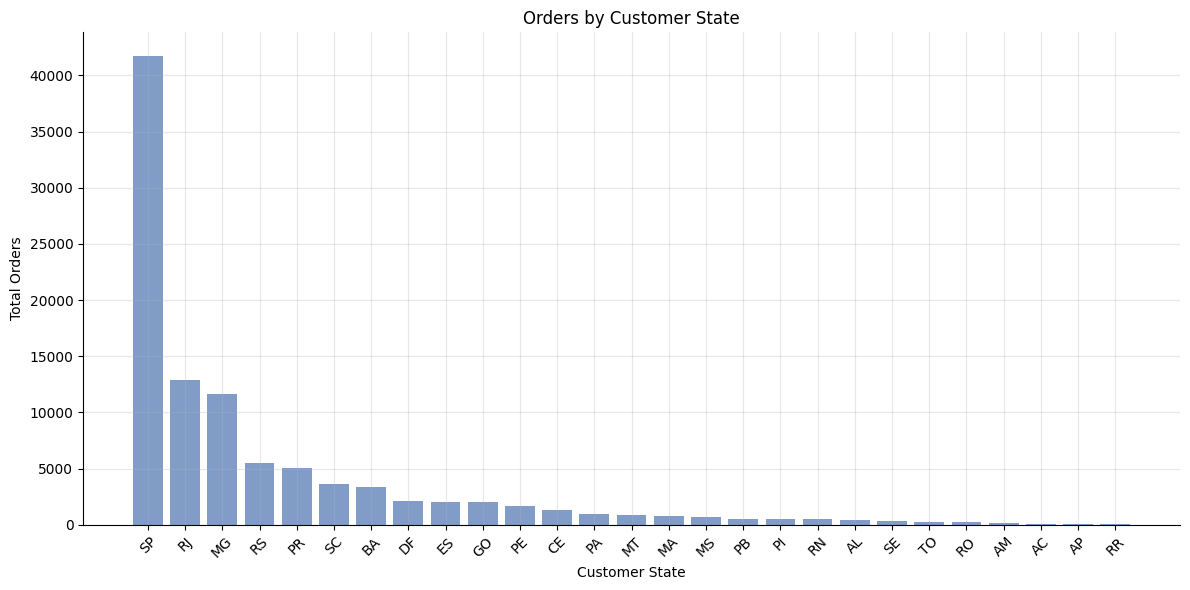

In [68]:
orders_by_state = q("""
  SELECT COUNT(o.order_id) AS total_orders, c.customer_state
  FROM olist_orders o
  JOIN olist_customers c ON o.customer_id = c.customer_id
  GROUP BY c.customer_state
  ORDER BY total_orders DESC
""")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(orders_by_state['customer_state'], orders_by_state['total_orders'], color="#4C72B0", alpha=0.7)
ax.set_xlabel('Customer State')
ax.set_ylabel('Total Orders')
ax.set_title('Orders by Customer State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.14 GROUP BY multiple columns

Group by more than one column to get finer breakdowns.

Count orders per status per state.

In [36]:
q("""
  SELECT 
    COUNT(o.order_id) AS total_orders,
    o.order_status,
    c.customer_state
  FROM olist_orders o
  JOIN olist_customers c ON o.customer_id = c.customer_id
  GROUP BY o.order_status, c.customer_state
  ORDER BY total_orders DESC
  LIMIT 5
""")

,total_orders,order_status,customer_state
0,40501,delivered,SP
1,12350,delivered,RJ
2,11354,delivered,MG
3,5345,delivered,RS
4,4923,delivered,PR


### 2.15 HAVING

Filter groups after aggregation. `WHERE` filters rows before grouping. `HAVING` filters groups after grouping.

Return states with more than 5,000 orders.

In [37]:
q("""
  SELECT 
    COUNT(o.order_id) AS order_count, c.customer_state 
  FROM olist_orders o
  JOIN olist_customers c ON o.customer_id = c.customer_id
  GROUP BY c.customer_state
  HAVING COUNT(o.order_id) > 5000
  ORDER BY order_count DESC
  """)

,order_count,customer_state
0,41746,SP
1,12852,RJ
2,11635,MG
3,5466,RS
4,5045,PR


Return sellers with more than 100 orders AND more than $10,000 in revenue.

In [38]:
q("""
  SELECT 
    seller_id,
    COUNT(order_id) AS order_count,
    ROUND(SUM(price), 2) AS revenue
  FROM olist_order_items
  GROUP BY seller_id
  HAVING COUNT(order_id) > 100
    AND ROUND(SUM(price), 2) > 10000
  ORDER BY revenue DESC 
  LIMIT 5
""")

,seller_id,order_count,revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63
1,53243585a1d6dc2643021fd1853d8905,410,222776.05
2,4a3ca9315b744ce9f8e9374361493884,1987,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89


### 2.16 INNER JOIN

Combine rows from two tables where there is a match on both sides. Rows without a match are dropped.

Return orders with the customer's city and state.

In [39]:
q("""
  SELECT o.order_id, c.customer_city, c.customer_state
  FROM olist_orders o
  JOIN olist_customers c ON o.customer_id = c.customer_id
  LIMIT 5
""")

,order_id,customer_city,customer_state
0,5f79b5b0931d63f1a42989eb65b9da6e,osasco,SP
1,a44895d095d7e0702b6a162fa2dbeced,itapecerica,MG
2,316a104623542e4d75189bb372bc5f8d,nova venecia,ES
3,5825ce2e88d5346438686b0bba99e5ee,mendonca,MG
4,0ab7fb08086d4af9141453c91878ed7a,sao paulo,SP


Return order items with the seller's city and state.

In [40]:
q("""
  SELECT oi.order_id, s.seller_id, s.seller_city, s.seller_state 
    FROM olist_order_items oi
    JOIN olist_sellers s ON oi.seller_id = s.seller_id
    LIMIT 5
""")

,order_id,seller_id,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,loanda,PR


### 2.17 LEFT JOIN

Return all rows from the left table. If there is no match on the right, NULLs fill in. Use when you want to keep rows even if there is no match.

Return all orders with their review score NULL if no review exists.

In [41]:
q("""
  SELECT * FROM olist_order_reviews LIMIT 1
""")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18,2018-01-18 21:46:59


In [42]:
q("""
  SELECT o.order_id, o.order_status, r.review_score
  FROM olist_orders o
  LEFT JOIN olist_order_reviews r ON o.order_id = r.order_id
  LIMIT 5
""")

,order_id,order_status,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,5
1,00018f77f2f0320c557190d7a144bdd3,delivered,4
2,000229ec398224ef6ca0657da4fc703e,delivered,5
3,00024acbcdf0a6daa1e931b038114c75,delivered,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,5


Return orders that have NO review at all. (LEFT JOIN + IS NULL pattern)

In [43]:
q("""
  SELECT o.order_id, o.order_status, o.order_purchase_timestamp
  FROM olist_orders o
  LEFT JOIN olist_order_reviews r ON o.order_id = r.order_id
  WHERE r.review_score IS NULL
  LIMIT 5
""")

,order_id,order_status,order_purchase_timestamp
0,de09bc4ff6a9de96b6895cd565f80e69,delivered,2017-03-11 19:23:25
1,94ab04bddd7b1b7e183c95cce062c3f5,delivered,2017-07-05 17:00:12
2,c9653cca1e27f0816402332712a4c87f,delivered,2017-11-24 19:53:18
3,1286029258c6e6c886f266c096f92db5,delivered,2018-04-09 13:11:55
4,5e682664f3f3651fbaf00a25915ef580,delivered,2018-03-07 12:27:19


### 2.18 Multi-table JOIN

Chain multiple JOINs to bring together more than two tables. Note: `olist_products` stores category names in Portuguese join to `olist_product_category_name_translation` to get English names.

Return order items with both the Portuguese and English category name.

In [44]:
q("""
  SELECT * FROM olist_products LIMIT 1
""")

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225.0,16.0,10.0,14.0


In [45]:
q("""
  SELECT * FROM olist_product_category_name_translation LIMIT 1
""")

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty


In [46]:
q("""
  SELECT
    oi.order_id,
    oi.price,
    p.product_category_name AS category_pt,
    t.product_category_name_english AS category_en
  FROM olist_order_items oi
  JOIN olist_products p ON oi.product_id = p.product_id
  LEFT JOIN olist_product_category_name_translation t ON p.product_category_name = t.product_category_name
  LIMIT 5
""")

,order_id,price,category_pt,category_en
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,239.90,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,199.00,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,12.99,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,ferramentas_jardim,garden_tools


Return full order detail: customer city/state, English category name, and price.

In [47]:
q("""
  SELECT
    o.order_id,
    c.customer_city,
    c.customer_state,
    t.product_category_name_english,
    oi.price
  FROM olist_orders o
  JOIN olist_customers c ON o.customer_id = c.customer_id
  JOIN olist_order_items oi ON o.order_id = oi.order_id
  JOIN olist_products p ON oi.product_id = p.product_id
  LEFT JOIN olist_product_category_name_translation t ON p.product_category_name = t.product_category_name
  LIMIT 5
""")

,order_id,customer_city,customer_state,product_category_name_english,price
0,00010242fe8c5a6d1ba2dd792cb16214,campos dos goytacazes,RJ,cool_stuff,58.90
1,00018f77f2f0320c557190d7a144bdd3,santa fe do sul,SP,pet_shop,239.90
2,000229ec398224ef6ca0657da4fc703e,para de minas,MG,furniture_decor,199.00
3,00024acbcdf0a6daa1e931b038114c75,atibaia,SP,perfumery,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,varzea paulista,SP,garden_tools,199.90


### 2.19 Aggregations with JOINs

Combine GROUP BY with multi-table queries to aggregate across related data.

Return total revenue and order count by month. Plot as a dual-axis chart.

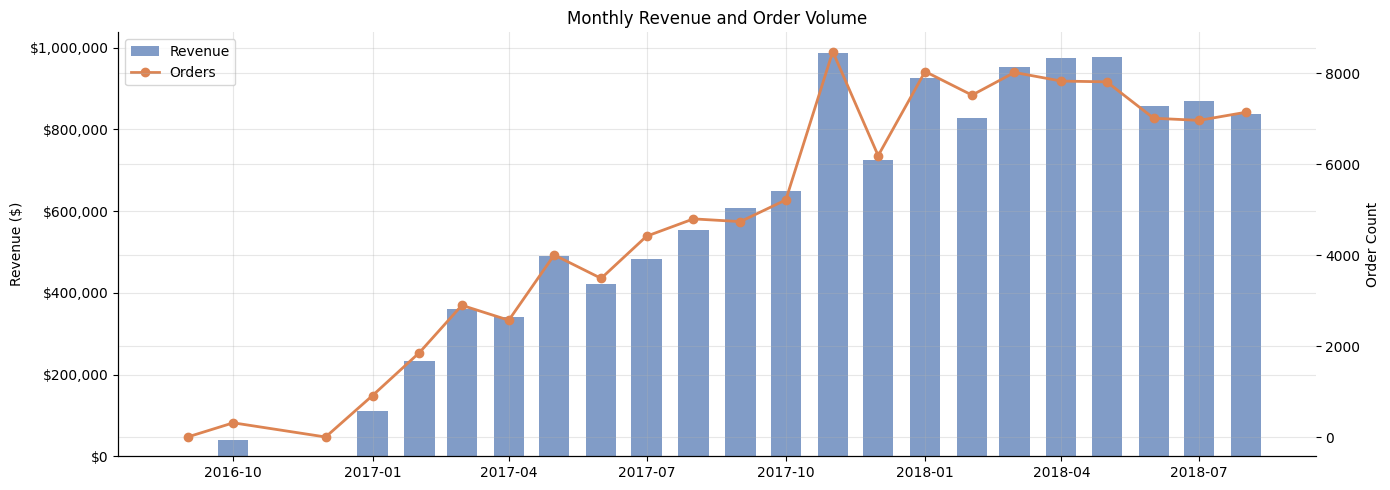

In [48]:
monthly = q("""
  SELECT 
    DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
    COUNT(o.order_id) AS order_count,
    ROUND(SUM(oi.price), 2) AS revenue
  FROM olist_orders o
  JOIN olist_order_items oi ON o.order_id = oi.order_id
  WHERE o.order_status = 'delivered'
  GROUP BY month
  ORDER BY month ASC
""")

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from datetime import timedelta

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(monthly["month"], monthly["revenue"], color="#4C72B0", alpha=0.7, 
        label="Revenue", width=timedelta(days=20))
ax2.plot(monthly["month"], monthly["order_count"], color="#DD8452", linewidth=2, marker="o", label="Orders")
ax1.set_ylabel("Revenue ($)")
ax2.set_ylabel("Order Count")
ax1.set_title("Monthly Revenue and Order Volume")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

This chart reveals an interesting divergence. Order volume peaked in November 2017 and plateaued through 2018, yet revenue continued to climb. This suggests that average order value increased over time; customers were placing fewer incremental orders but spending more per transaction.

Return top 10 product categories by revenue using English names. Plot as a horizontal bar chart.

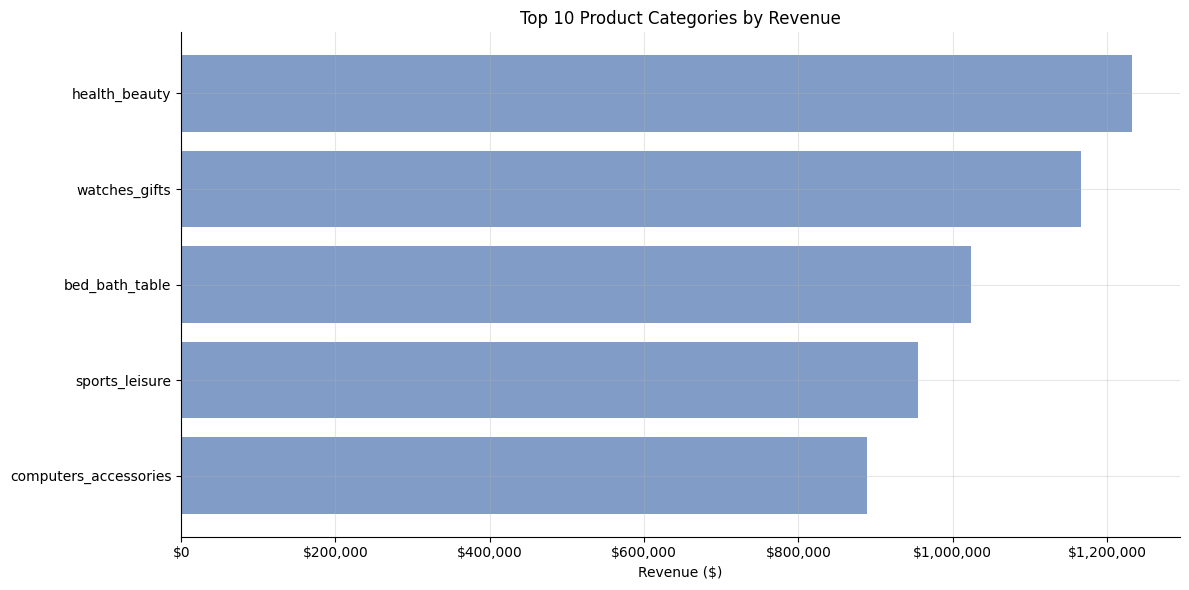

In [49]:
top_categories = q("""
  SELECT
    t.product_category_name_english AS category,
    COUNT(o.order_id) AS order_count,
    ROUND(SUM(oi.price), 2) AS revenue
  FROM olist_product_category_name_translation t
  JOIN olist_products p ON t.product_category_name = p.product_category_name
  JOIN olist_order_items oi ON p.product_id = oi.product_id
  JOIN olist_orders o ON oi.order_id = o.order_id
  WHERE o.order_status = 'delivered'
  GROUP BY t.product_category_name_english
  ORDER BY revenue DESC
  LIMIT 5
""")

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_categories["category"], top_categories["revenue"], color="#4C72B0", alpha=0.7)
ax.set_xlabel("Revenue ($)")
ax.set_title("Top 10 Product Categories by Revenue")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 2.20 CASE WHEN

Conditional logic inside a query. Evaluates conditions top to bottom and returns the first match.

Label each delivered order as 'fast' (≤3 days), 'normal' (≤7 days), or 'slow'.

In [50]:
q("""
  SELECT
    order_id,
    DATE_PART('day', order_delivered_customer_date - order_purchase_timestamp) AS delivery_days,
    CASE
      WHEN DATE_PART('day', order_delivered_customer_date - order_purchase_timestamp) <= 3 THEN 'fast'
      WHEN DATE_PART('day', order_delivered_customer_date - order_purchase_timestamp) <= 7 THEN 'normal'
      ELSE 'slow'
    END AS delivery_speed
  FROM olist_orders
  WHERE order_status = 'delivered'
    AND order_delivered_customer_date IS NOT NULL
  LIMIT 5
""")

,order_id,delivery_days,delivery_speed
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,slow
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,slow
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,slow
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,slow
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,fast


Count orders by delivery speed label.

In [51]:
q("""
  SELECT
    CASE
      WHEN DATE_PART('day', order_delivered_customer_date - order_purchase_timestamp) <= 3 THEN 'fast'
      WHEN DATE_PART('day', order_delivered_customer_date - order_purchase_timestamp) <= 7 THEN 'normal'
      ELSE 'slow'
    END AS delivery_speed,
    COUNT(*) AS order_count
  FROM olist_orders
  WHERE order_status = 'delivered'
    AND order_delivered_customer_date IS NOT NULL
  GROUP BY delivery_speed
  ORDER BY order_count DESC
""")

,delivery_speed,order_count
0,slow,62774
1,normal,25094
2,fast,8602


### 2.21 COALESCE

Return the first non-NULL value from a list. Used to substitute a default when a value is missing.

Return product IDs with their category replace NULL with 'unknown'.

In [52]:
q("""
  SELECT 
    product_id,
    COALESCE(product_category_name, 'unknown') AS category
  FROM olist_products
  LIMIT 5
""")

,product_id,category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas


Return reviews with their comment replace NULL comment with 'no comment'.

In [53]:
q("""
  SELECT 
    review_id, 
    COALESCE(review_comment_message, 'no comment') AS comment
  FROM olist_order_reviews
  LIMIT 5  
""")

,review_id,comment
0,7bc2406110b926393aa56f80a40eba40,no comment
1,80e641a11e56f04c1ad469d5645fdfde,no comment
2,228ce5500dc1d8e020d8d1322874b6f0,no comment
3,e64fb393e7b32834bb789ff8bb30750e,Recebi bem antes do prazo estipulado.
4,f7c4243c7fe1938f181bec41a392bdeb,Parabéns lojas lannister adorei comprar pela I...


### 2.22 Subqueries

A query nested inside another query. Can be used in WHERE (filter by a computed list), FROM (treat result as a table), or SELECT (compute a value per row).

Return orders placed by customers from SP, using a subquery in WHERE.

In [54]:
q("""
  SELECT order_id, order_status, order_purchase_timestamp
  FROM olist_orders
  WHERE customer_id IN (
      SELECT customer_id
      FROM olist_customers
      WHERE customer_state = 'SP'
  )
  LIMIT 5
""")

,order_id,order_status,order_purchase_timestamp
0,5f79b5b0931d63f1a42989eb65b9da6e,delivered,2017-11-14 16:08:26
1,0ab7fb08086d4af9141453c91878ed7a,delivered,2018-04-02 13:42:17
2,cd3558a10d854487b4f907e9b326a4fc,delivered,2017-04-12 08:35:12
3,263ba12390d0fbce329dd16da8cd20f8,delivered,2018-06-20 09:46:53
4,c208db5638f7f1cd04d185856852f864,delivered,2017-03-15 23:44:09


Return products heavier than the average product weight.

In [55]:
q("""
  SELECT product_id, product_category_name, product_weight_g
  FROM olist_products
  WHERE product_weight_g > (
      SELECT ROUND(AVG(product_weight_g), 2)
      FROM olist_products
  )
  ORDER BY product_weight_g DESC
  LIMIT 5
""")

,product_id,product_category_name,product_weight_g
0,26644690fde745fc4654719c3904e1db,cama_mesa_banho,40425.0
1,53f92b0474f91fcb5bd188c6a8075c38,utilidades_domesticas,30000.0
2,d0877f0094337c414d23f5a3c7bad20c,moveis_escritorio,30000.0
3,ceeba7d5636e59173cc5f484e913db3d,NaN,30000.0
4,f97ad9066c718a6cef93dfcf253d3e0d,moveis_decoracao,30000.0


### 2.23 CTEs (WITH)

A named subquery defined at the top of a query. Makes complex queries readable by breaking them into steps. Think of it as a temporary table that only exists for that query.

Use a CTE to find customers who spent more than the average customer.

In [56]:
q("""
  WITH customer_spend AS (
      SELECT
        c.customer_unique_id,
        ROUND(SUM(oi.price), 2) AS total_spent
      FROM olist_customers c
      JOIN olist_orders o ON c.customer_id = o.customer_id
      JOIN olist_order_items oi ON o.order_id = oi.order_id
      WHERE o.order_status = 'delivered'
      GROUP BY 1
  )
  SELECT *
  FROM customer_spend
  WHERE total_spent > (
      SELECT ROUND(AVG(total_spent), 2)
      FROM customer_spend
  )
  ORDER BY total_spent DESC
  LIMIT 5
""")


,customer_unique_id,total_spent
0,0a0a92112bd4c708ca5fde585afaa872,13440.0
1,da122df9eeddfedc1dc1f5349a1a690c,7388.0
2,763c8b1c9c68a0229c42c9fc6f662b93,7160.0
3,dc4802a71eae9be1dd28f5d788ceb526,6735.0
4,459bef486812aa25204be022145caa62,6729.0


Use a CTE to calculate month-over-month revenue change with LAG.

In [57]:
q("""
  WITH monthly AS (
    SELECT
      DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
      ROUND(SUM(oi.price), 2) AS revenue
    FROM olist_orders o
    JOIN olist_order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
  )
  SELECT 
    month, 
    revenue,
    LAG(revenue) OVER (ORDER BY month) AS previous_month_revenue,
    ROUND(
        (revenue - LAG(revenue) OVER (ORDER BY month)) 
        / NULLIF(LAG(revenue) OVER (ORDER BY month), 0) * 100, 1
    ) AS revenue_growth_pct
  FROM monthly
  ORDER BY month ASC
  LIMIT 5
""")

,month,revenue,previous_month_revenue,revenue_growth_pct
0,2016-09-01,134.97,NaN,NaN
1,2016-10-01,40325.11,134.97,29777.1
2,2016-12-01,10.90,40325.11,-100.0
3,2017-01-01,111798.36,10.90,1025573.0
4,2017-02-01,234223.40,111798.36,109.5


### 2.24 Window Functions ROW_NUMBER, RANK, DENSE_RANK

Calculations across rows without collapsing into a group. Very common in interviews.

- `ROW_NUMBER()` unique sequential number per row, no ties
- `RANK()` tied rows share the same rank, next rank skips (1, 2, 2, 4)
- `DENSE_RANK()` tied rows share the same rank, no skipping (1, 2, 2, 3)

Rank sellers by total revenue using RANK and DENSE_RANK.

In [58]:
q("""
  SELECT 
    seller_id,
    ROUND(SUM(price), 2) AS revenue,
    RANK() OVER (ORDER BY SUM(price) DESC) AS rank,
    DENSE_RANK() OVER (ORDER BY SUM(price) DESC) AS dense_rank
  FROM olist_order_items
  GROUP BY seller_id
  ORDER BY revenue DESC
  LIMIT 5
""")

,seller_id,revenue,rank,dense_rank
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1,1
1,53243585a1d6dc2643021fd1853d8905,222776.05,2,2
2,4a3ca9315b744ce9f8e9374361493884,200472.92,3,3
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,4,4
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,5,5


### 2.25 PARTITION BY

Apply a window function within groups. Like GROUP BY but without collapsing rows each row keeps its own values while still seeing the group-level calculation.

Rank sellers by revenue within each state.

In [59]:
q("""
  SELECT
    s.seller_state,
    oi.seller_id,
    ROUND(SUM(oi.price), 2) AS revenue,
    RANK() OVER (PARTITION BY s.seller_state ORDER BY SUM(oi.price) DESC) AS state_rank
  FROM olist_order_items oi
  JOIN olist_sellers s ON oi.seller_id = s.seller_id
  GROUP BY s.seller_state, oi.seller_id
  ORDER BY s.seller_state ASC, state_rank ASC
  LIMIT 10
""")

,seller_state,seller_id,revenue,state_rank
0,AC,4be2e7f96b4fd749d52dff41f80e39dd,267.00,1
1,AM,327b89b872c14d1c0be7235ef4871685,1177.00,1
2,BA,53243585a1d6dc2643021fd1853d8905,222776.05,1
3,BA,c72de06d72748d1a0dfb2125be43ba63,17522.00,2
4,BA,75d34ebb1bd0bd7dde40dd507b8169c3,15048.28,3
5,BA,d03698c2efd04a549382afa6623e27fb,8865.47,4
6,BA,4aba391bc3b88717ce08eb11e44937b2,7595.87,5
7,BA,a3dd39f583bc80bd8c5901c95878921e,4607.81,6
8,BA,1444c08e64d55fb3c25f0f09c07ffcf2,2749.00,7
9,BA,659e8466eb3ff1b0e8740d74fb7bbedd,1486.80,8


Return the most recent order per customer using ROW_NUMBER and PARTITION BY.

In [60]:
q("""
  WITH ranked AS (
    SELECT
      c.customer_unique_id,
      o.order_id,
      o.order_purchase_timestamp,
      ROW_NUMBER() OVER (
          PARTITION BY c.customer_unique_id
          ORDER BY o.order_purchase_timestamp DESC
      ) AS rn
    FROM olist_customers c
    JOIN olist_orders o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
  )
  SELECT customer_unique_id, order_id, order_purchase_timestamp
  FROM ranked
  WHERE rn = 1
  ORDER BY order_purchase_timestamp DESC
  LIMIT 5
""")

,customer_unique_id,order_id,order_purchase_timestamp
0,24ac2b4327e25baf39f2119e4228976a,35a972d7f8436f405b56e36add1a7140,2018-08-29 15:00:37
1,b701bebbdf478f5500348f03aff62121,03ef5dedbe7492bdae72eec50764c43f,2018-08-29 14:52:00
2,7febafa06d9d8f232a900a2937f04338,168626408cb32af0ffaf76711caae1dc,2018-08-29 14:18:28
3,5c58de6fb80e93396e2f35642666b693,0b223d92c27432930dfe407c6aea3041,2018-08-29 14:18:23
4,7a22d14aa3c3599238509ddca4b93b01,52018484704db3661b98ce838612b507,2018-08-29 12:25:59


### 2.26 LAG, LEAD

Access the value from the previous row (LAG) or next row (LEAD) within an ordered set. Used to compare each row against its neighbour.

Return daily revenue with the previous and next day's revenue for comparison.

In [61]:
q("""
  WITH daily AS (
    SELECT
      DATE_TRUNC('day', o.order_purchase_timestamp) AS day,
      ROUND(SUM(oi.price), 2) AS revenue
    FROM olist_orders o
    JOIN olist_order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
  )
  SELECT 
    day, 
    revenue,
    LAG(revenue) OVER (ORDER BY day) AS prev_day_revenue,
    LEAD(revenue) OVER (ORDER BY day) AS next_day_revenue
  FROM daily
  ORDER BY day ASC
  LIMIT 5
""")

,day,revenue,prev_day_revenue,next_day_revenue
0,2016-09-15,134.97,NaN,441.98
1,2016-10-03,441.98,134.97,8595.89
2,2016-10-04,8595.89,441.98,6169.77
3,2016-10-05,6169.77,8595.89,5889.96
4,2016-10-06,5889.96,6169.77,6075.35


### 2.27 Running Totals

Use `SUM` with `ORDER BY` inside `OVER` to accumulate a value row by row over time.

Return cumulative revenue over time and plot as a filled area chart.

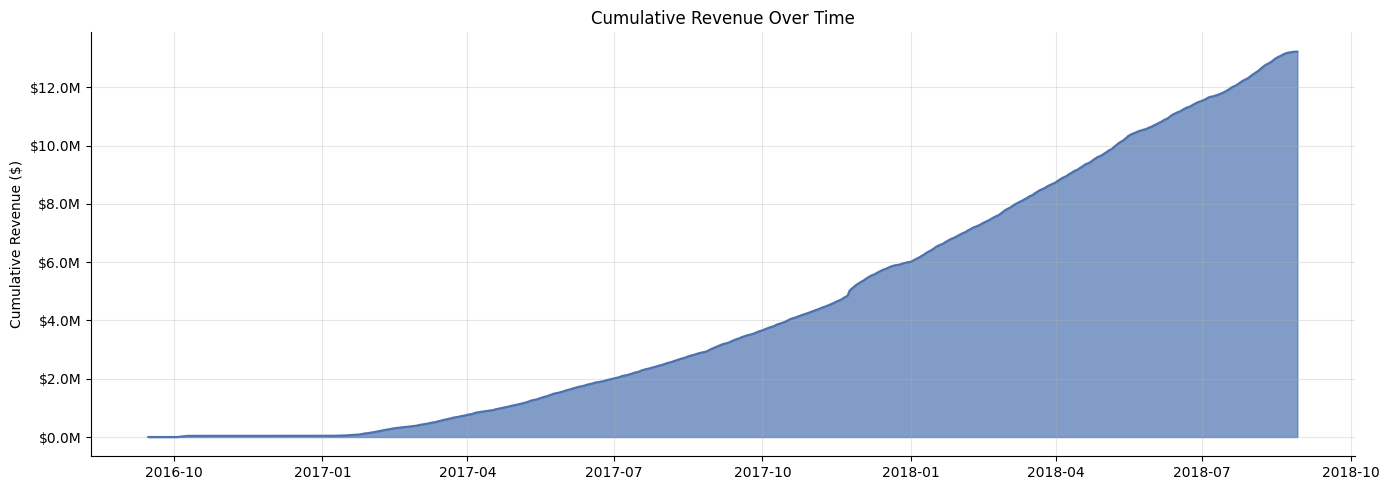

In [62]:
running = q("""
  WITH daily AS (
    SELECT
      DATE_TRUNC('day', o.order_purchase_timestamp) AS day,
      ROUND(SUM(oi.price), 2) AS daily_revenue
    FROM olist_orders o
    JOIN olist_order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
  )
  SELECT
    day,
    daily_revenue,
    ROUND(SUM(daily_revenue) OVER (ORDER BY day), 2) AS cumulative_revenue
    FROM daily
    ORDER BY day ASC
""")

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(running["day"], running["cumulative_revenue"], color="#4C72B0", alpha=0.7)
ax.plot(running["day"], running["cumulative_revenue"], color="#4C72B0", linewidth=1.5)
ax.set_ylabel("Cumulative Revenue ($)")
ax.set_title("Cumulative Revenue Over Time")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

### 2.28 NTILE

Divide rows into N equal buckets. Used for quartiles (4), deciles (10), or percentiles (100).

Divide sellers into 4 quartiles by total revenue.

In [63]:
q("""
  SELECT 
    seller_id,
    ROUND(SUM(price), 2) AS revenue,
    NTILE(4) OVER (ORDER BY SUM(price) DESC) AS quartile
  FROM olist_order_items
  GROUP BY seller_id
  ORDER BY revenue DESC
  LIMIT 5
""")

,seller_id,revenue,quartile
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1
1,53243585a1d6dc2643021fd1853d8905,222776.05,1
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,1
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,1


### 2.29 NULLIF

Returns NULL if two values are equal. Most commonly used to avoid division by zero dividing by NULLIF(x, 0) returns NULL instead of an error when x is 0.

Return the on-time delivery rate per state. Use NULLIF to prevent division by zero.

In [64]:
q("""
  SELECT 
    c.customer_state,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date THEN 1 ELSE 0 END) AS on_time,
    ROUND(
        SUM(CASE WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date THEN 1 ELSE 0 END)
        * 100.0 / NULLIF(COUNT(*), 0), 1) AS on_time_pct
  FROM olist_orders o
  JOIN olist_customers c ON o.customer_id = c.customer_id
  WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
  GROUP BY c.customer_state
  ORDER BY on_time_pct DESC
  LIMIT 10
""")

,customer_state,total_orders,on_time,on_time_pct
0,RO,243,236,97.1
1,AC,80,77,96.3
2,AM,145,139,95.9
3,AP,67,64,95.5
4,PR,4923,4677,95.0
5,MG,11354,10717,94.4
6,SP,40494,38107,94.1
7,MT,886,826,93.2
8,DF,2080,1933,92.9
9,RS,5344,4962,92.9


### 2.30 Date Functions

Postgres provides functions for extracting parts of a timestamp (`DATE_PART`) and truncating to a time boundary (`DATE_TRUNC`). Use `DATE_PART('dow', ...)` for day of week (0=Sunday).

Extract year, month, and day of week from `order_purchase_timestamp`.

In [65]:
q("""
  SELECT
    order_id,
    order_purchase_timestamp,
    DATE_PART('year', order_purchase_timestamp) AS purchase_year,
    DATE_PART('month', order_purchase_timestamp) AS purchase_month,
    DATE_PART('dow', order_purchase_timestamp) AS day_of_week
  FROM olist_orders
  LIMIT 5
""")

,order_id,order_purchase_timestamp,purchase_year,purchase_month,day_of_week
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017.0,10.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018.0,7.0,2.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018.0,8.0,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017.0,11.0,6.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018.0,2.0,2.0


Count orders by day of week and plot as a bar chart.

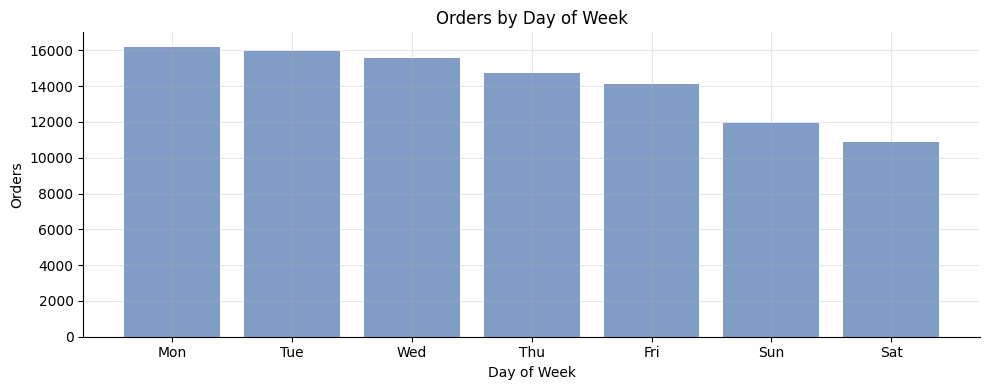

In [66]:
dow = q("""
  SELECT
    DATE_PART('dow', order_purchase_timestamp) AS day_of_week,
    COUNT(*) AS order_count
  FROM olist_orders
  GROUP BY day_of_week
  ORDER BY order_count DESC
""")

import matplotlib.pyplot as plt
days = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([days[int(d)] for d in dow["day_of_week"]], dow["order_count"], color="#4C72B0", alpha=0.7)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Orders")
ax.set_title("Orders by Day of Week")
plt.tight_layout()
plt.show()

Calculate how many days each delivered order took from purchase to delivery.

In [67]:
q("""
  SELECT 
    order_id,
    DATE_PART('day', order_delivered_customer_date - order_purchase_timestamp) AS delivery_days
  FROM olist_orders
  WHERE order_status = 'delivered'
    AND order_delivered_customer_date IS NOT NULL
  ORDER BY delivery_days DESC
    LIMIT 5
""")

,order_id,delivery_days
0,ca07593549f1816d26a572e06dc1eab6,209.0
1,1b3190b2dfa9d789e1f14c05b647a14a,208.0
2,440d0d17af552815d15a9e41abe49359,195.0
3,2fb597c2f772eca01b1f5c561bf6cc7b,194.0
4,285ab9426d6982034523a855f55a885e,194.0
